
# CS412 — Machine Learning — Homework 1 (k-NN on Fashion-MNIST)

**Student:** *Ulukan Keskin*  
**Notebook Filename:** CS412-HW1-UlukanKeskin.ipynb

**Date:** 2025-10-18

**Shareable link to notebook:**  
Paste your GitHub/Drive/Share URL here once you upload the notebook.



## 1) Environment & Dependencies

Run the following cell **once** if needed to install dependencies in your environment.  
If you're in VS Code, make sure your selected Python interpreter has these packages.


In [1]:
#%pip install -q numpy pandas matplotlib scikit-learn tensorflow
#%pip install -q seaborn


## 2) Imports & Global Configuration


In [2]:

import os, time, random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_recall_fscore_support, ConfusionMatrixDisplay
)


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120

FASHION_CLASSES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]



## 3) Dataset Loading

We use Fashion-MNIST from Keras.  
We will split the training set into *train* and *validation* using a *stratified* split.


In [3]:

from tensorflow.keras.datasets import fashion_mnist

# load data
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

print("Original shapes:")
print("Train full:", X_train_full.shape, y_train_full.shape)
print("Test:", X_test.shape, y_test.shape)

# create train/validation split from the original training set
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train_full,
    shuffle=True
)

print("\nAfter split:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)


Original shapes:
Train full: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)

After split:
X_train: (48000, 28, 28) y_train: (48000,)
X_val  : (12000, 28, 28) y_val  : (12000,)
X_test : (10000, 28, 28) y_test : (10000,)



## 4) Exploratory Data Analysis (EDA)

Will inspect:
1. **Class distribution** in the training set.
2. **Pixel statistics**: global mean/std and per-class mean intensity.
3. **Visualize one sample per class**.


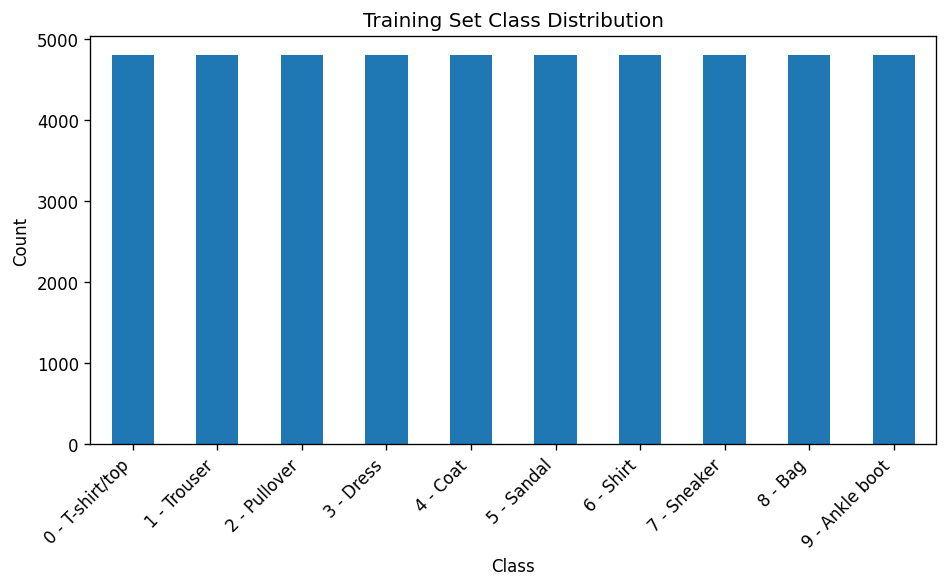

,class_id,class_name,count
0,0,T-shirt/top,4800
1,1,Trouser,4800
2,2,Pullover,4800
3,3,Dress,4800
4,4,Coat,4800
5,5,Sandal,4800
6,6,Shirt,4800
7,7,Sneaker,4800
8,8,Bag,4800
9,9,Ankle boot,4800


In [4]:

train_counts = pd.Series(y_train).value_counts().sort_index()
fig, ax = plt.subplots()
train_counts.plot(kind="bar", ax=ax)
ax.set_xticklabels([f"{i} - {FASHION_CLASSES[i]}" for i in train_counts.index], rotation=45, ha="right")
ax.set_title("Training Set Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

train_counts_df = pd.DataFrame({
    "class_id": train_counts.index,
    "class_name": [FASHION_CLASSES[i] for i in train_counts.index],
    "count": train_counts.values
})
train_counts_df


Global mean (train): 72.99
Global std  (train): 90.06



,class_id,class_name,mean_intensity
0,0,T-shirt/top,82.849735
1,1,Trouser,56.987135
2,2,Pullover,96.491521
3,3,Dress,66.121778
4,4,Coat,98.100238
5,5,Sandal,34.800133
6,6,Shirt,84.826124
7,7,Sneaker,42.837788
8,8,Bag,90.169411
9,9,Ankle boot,76.760902


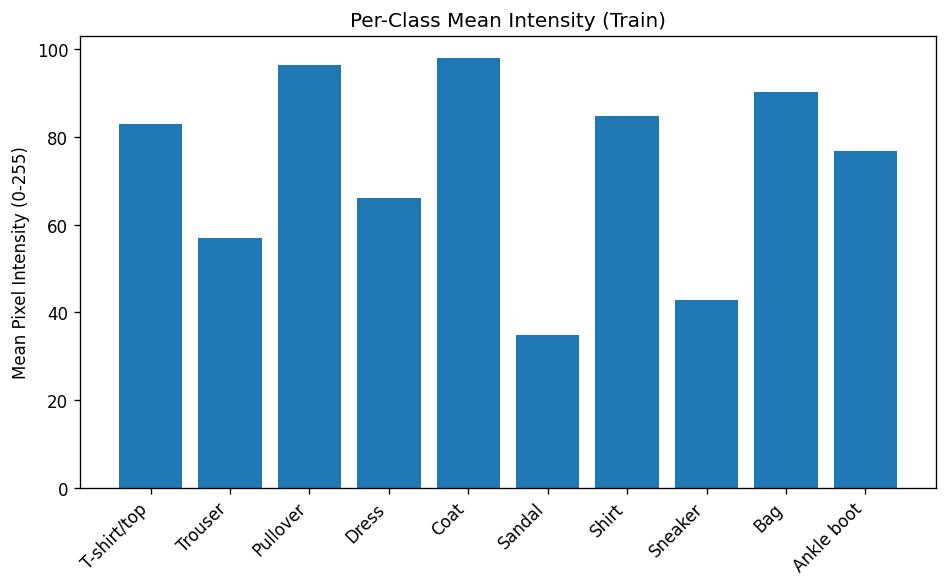

In [5]:

global_mean = X_train.mean()
global_std  = X_train.std()

per_class_means = []
for cid in range(10):
    per_class_means.append(X_train[y_train == cid].mean())
per_class_means = np.array(per_class_means)

print(f"Global mean (train): {global_mean:.2f}")
print(f"Global std  (train): {global_std:.2f}\n")

per_class_df = pd.DataFrame({
    "class_id": range(10),
    "class_name": FASHION_CLASSES,
    "mean_intensity": per_class_means
})
display(per_class_df)

fig, ax = plt.subplots()
ax.bar(range(10), per_class_means)
ax.set_xticks(range(10))
ax.set_xticklabels(FASHION_CLASSES, rotation=45, ha="right")
ax.set_ylabel("Mean Pixel Intensity (0-255)")
ax.set_title("Per-Class Mean Intensity (Train)")
plt.tight_layout()
plt.show()


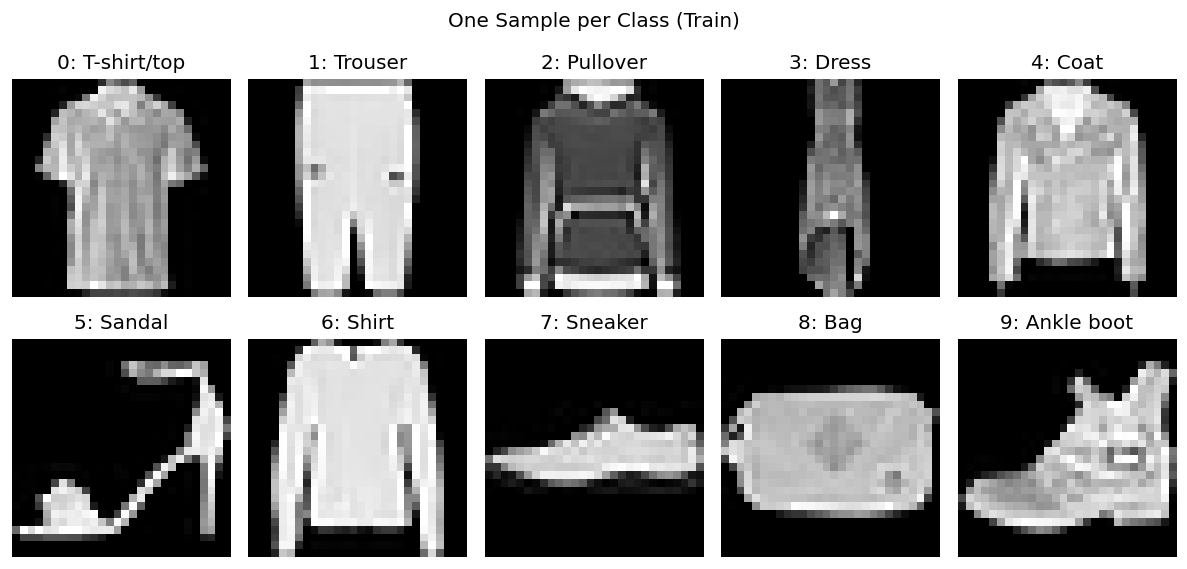

In [6]:

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()
for cid in range(10):
    idxs = np.where(y_train == cid)[0]
    idx = np.random.choice(idxs)
    axes[cid].imshow(X_train[idx], cmap="gray")
    axes[cid].set_title(f"{cid}: {FASHION_CLASSES[cid]}")
    axes[cid].axis("off")
plt.suptitle("One Sample per Class (Train)")
plt.tight_layout()
plt.show()



## 5) Preprocessing

- **Flatten** each 28×28 image to a 784-dim vector (required by scikit-learn).
- **Standardize** features using `StandardScaler` (**fit on train only**, apply to val/test).
We will print the mean/std before and after to confirm the effect.


In [7]:

# flatten
X_train_flat = X_train.reshape(len(X_train), -1).astype(np.float32)
X_val_flat   = X_val.reshape(len(X_val), -1).astype(np.float32)
X_test_flat  = X_test.reshape(len(X_test), -1).astype(np.float32)

print("Before scaling:")
print("Train mean/std:", X_train_flat.mean(), X_train_flat.std())

# standardize
scaler = StandardScaler(with_mean=True, with_std=True)
X_train_std = scaler.fit_transform(X_train_flat)
X_val_std   = scaler.transform(X_val_flat)
X_test_std  = scaler.transform(X_test_flat)

print("\nAfter scaling (train stats):")
print("Train mean/std:", X_train_std.mean().round(4), X_train_std.std().round(4))
print("Val   mean/std:", X_val_std.mean().round(4),   X_val_std.std().round(4))
print("Test  mean/std:", X_test_std.mean().round(4),  X_test_std.std().round(4))


Before scaling:
Train mean/std: 72.994446 90.0594

After scaling (train stats):
Train mean/std: 0.0 1.0
Val   mean/std: -0.0037 1.0088
Test  mean/std: 0.0018 1.0159



## 6) k-NN Hyperparameter Tuning (Validation)

We compare:
- **k** : {1, 3, 5, 7}
- **metric** : {`euclidean`, `manhattan`}

For each (k, metric), we fit on **train** and evaluate **validation accuracy**.


In [8]:

ks = [1, 3, 5, 7]
metrics = ["euclidean", "manhattan"]

records = []
for metric in metrics:
    for k in ks:
        clf = KNeighborsClassifier(n_neighbors=k, metric=metric, n_jobs=-1)
        t0 = time.perf_counter()
        clf.fit(X_train_std, y_train)
        fit_time = time.perf_counter() - t0

        t1 = time.perf_counter()
        y_val_pred = clf.predict(X_val_std)
        pred_time = time.perf_counter() - t1

        acc = accuracy_score(y_val, y_val_pred)
        records.append({
            "k": k, "metric": metric,
            "val_accuracy": acc,
            "fit_time_sec": fit_time,
            "pred_time_sec": pred_time
        })

results_df = pd.DataFrame(records).sort_values(["metric", "k"]).reset_index(drop=True)
results_df


,k,metric,val_accuracy,fit_time_sec,pred_time_sec
0,1,euclidean,0.852083,0.024239,5.986725
1,3,euclidean,0.855333,0.022592,4.837264
2,5,euclidean,0.854833,0.023566,4.613987
3,7,euclidean,0.856250,0.022606,4.670195
4,1,manhattan,0.857000,0.023073,61.644715
5,3,manhattan,0.863083,0.024312,60.825836
6,5,manhattan,0.866083,0.023579,61.877107
7,7,manhattan,0.864333,0.036373,63.683066


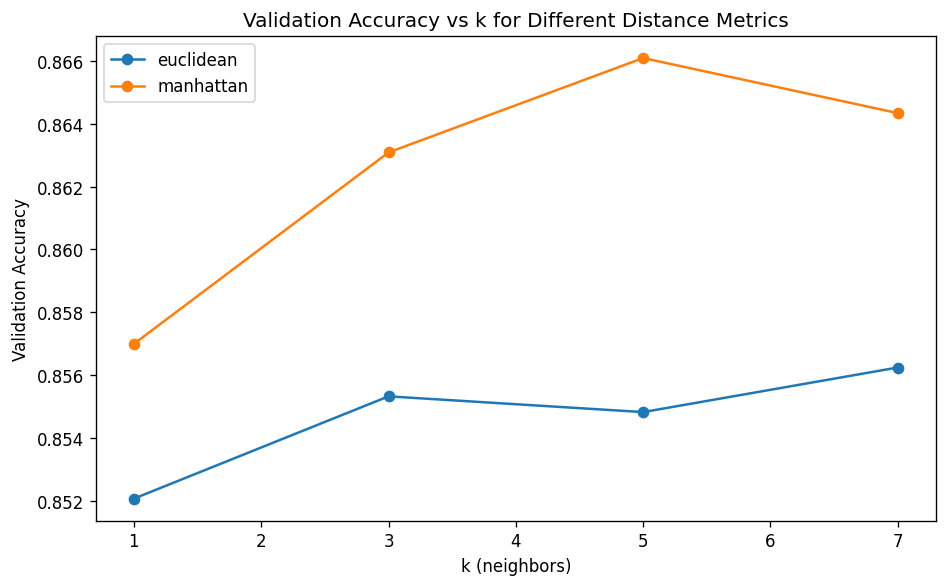

k                        5
metric           manhattan
val_accuracy      0.866083
fit_time_sec      0.023579
pred_time_sec    61.877107
Name: 6, dtype: object

In [9]:

# plot validation accuracy vs k for both metrics
fig, ax = plt.subplots()
for metric in metrics:
    subset = results_df[results_df["metric"] == metric]
    ax.plot(subset["k"], subset["val_accuracy"], marker="o", label=metric)
ax.set_xlabel("k (neighbors)")
ax.set_ylabel("Validation Accuracy")
ax.set_title("Validation Accuracy vs k for Different Distance Metrics")
ax.legend()
plt.tight_layout()
plt.show()

# choose best hyperparameters
best_row = results_df.sort_values(
    by=["val_accuracy", "k"], ascending=[False, True]
).iloc[0]
best_k = int(best_row["k"])
best_metric = str(best_row["metric"])
best_row



## 7) Final Model (Train on Train+Val, Evaluate on Test)

Using the best performing hyperparameters from validation, we re-fit k-NN on **train+val** and then evaluate on **test**.
We report:
- Overall **accuracy**
- **Macro** precision, recall, F1
- **Confusion matrix** (figure) with commentary
- **Timing**: fit & predict


Best hyperparams: k=5, metric=manhattan
Test Accuracy: 0.8613
Macro Precision: 0.8625, Macro Recall: 0.8613, Macro F1: 0.8609
Final Fit Time (s): 0.0289, Final Predict Time (s): 67.3165


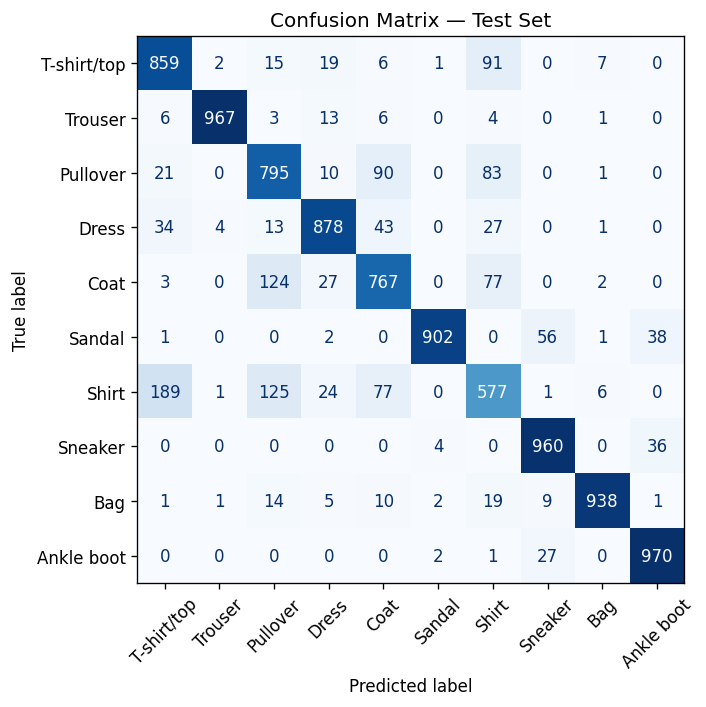

In [10]:
X_dev_std = np.vstack([X_train_std, X_val_std])
y_dev = np.concatenate([y_train, y_val])

final_clf = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric, n_jobs=-1)

t0 = time.perf_counter()
final_clf.fit(X_dev_std, y_dev)
final_fit_time = time.perf_counter() - t0

t1 = time.perf_counter()
y_test_pred = final_clf.predict(X_test_std)
final_pred_time = time.perf_counter() - t1

test_acc = accuracy_score(y_test, y_test_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average="macro", zero_division=0)
print(f"Best hyperparams: k={best_k}, metric={best_metric}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Macro Precision: {prec:.4f}, Macro Recall: {rec:.4f}, Macro F1: {f1:.4f}")
print(f"Final Fit Time (s): {final_fit_time:.4f}, Final Predict Time (s): {final_pred_time:.4f}")

# confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=range(10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=FASHION_CLASSES)
fig, ax = plt.subplots(figsize=(7,6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()


In [11]:

# Classification report (per-class P/R/F1)
report = classification_report(y_test, y_test_pred, target_names=FASHION_CLASSES, zero_division=0)
print(report)


              precision    recall  f1-score   support

 T-shirt/top       0.77      0.86      0.81      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.73      0.80      0.76      1000
       Dress       0.90      0.88      0.89      1000
        Coat       0.77      0.77      0.77      1000
      Sandal       0.99      0.90      0.94      1000
       Shirt       0.66      0.58      0.61      1000
     Sneaker       0.91      0.96      0.94      1000
         Bag       0.98      0.94      0.96      1000
  Ankle boot       0.93      0.97      0.95      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000




## 8) Error Analysis

We identify the **top 3 most confused class pairs** from the off-diagonal entries of the confusion matrix.  
For each pair (True=A, Pred=B), we display **5 random misclassified examples** with their true/predicted labels and add brief commentary.


In [12]:

# Find top-3 confused pairs from cm (off-diagonal max)
cm_off = cm.copy().astype(np.int64)
np.fill_diagonal(cm_off, 0)  # zero-out diagonal

pairs = []
for i in range(10):
    for j in range(10):
        if i != j and cm_off[i, j] > 0:
            pairs.append((i, j, cm_off[i, j]))
pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)

top3 = pairs_sorted[:3]
top3_named = [ (FASHION_CLASSES[i], FASHION_CLASSES[j], cnt, i, j) for i,j,cnt in top3 ]
top3_named


[('Shirt', 'T-shirt/top', 189, 6, 0),
 ('Shirt', 'Pullover', 125, 6, 2),
 ('Coat', 'Pullover', 124, 4, 2)]

Pair: True='Shirt' Pred='T-shirt/top' — count=189


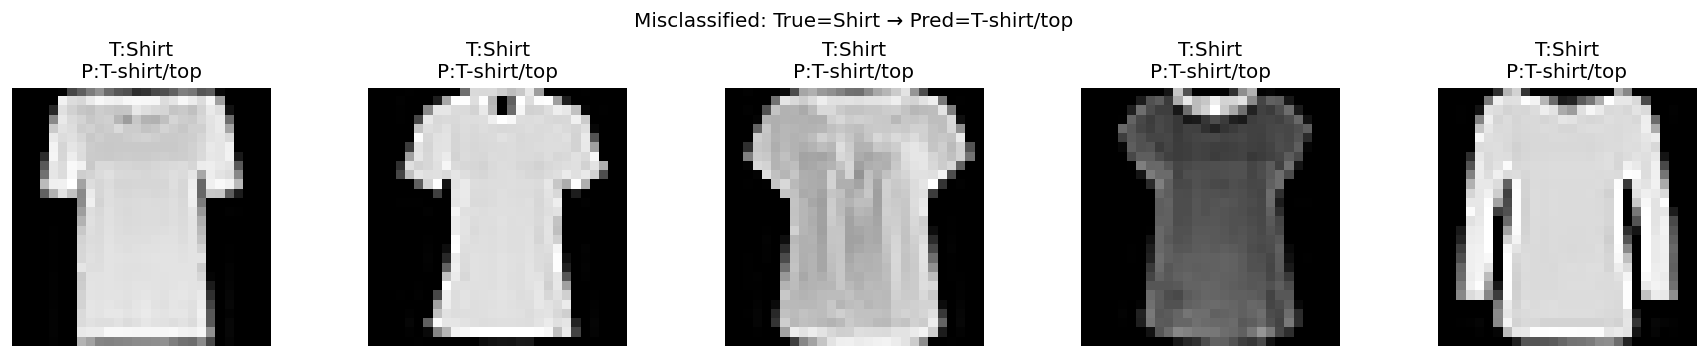

Pair: True='Shirt' Pred='Pullover' — count=125


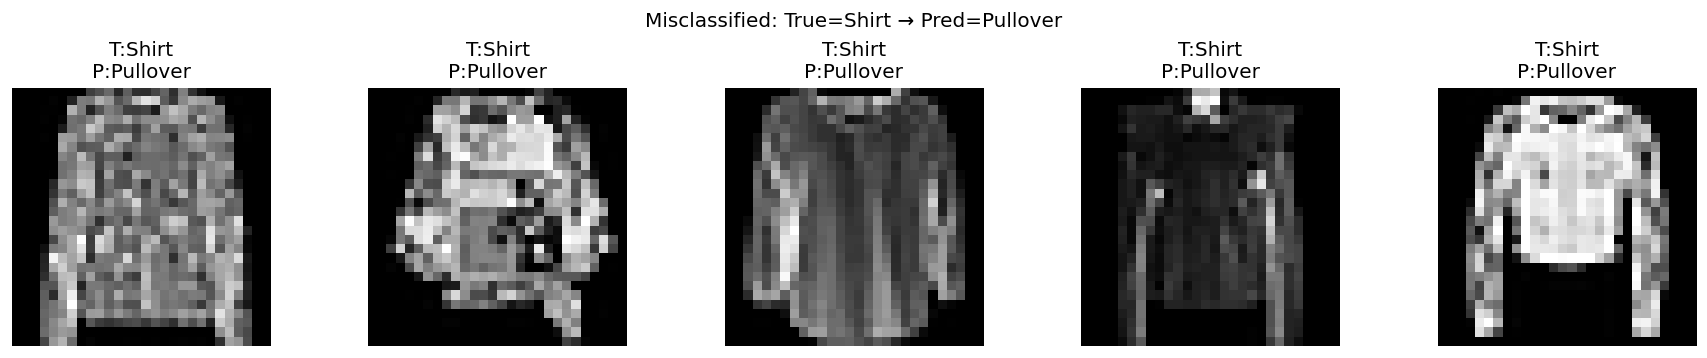

Pair: True='Coat' Pred='Pullover' — count=124


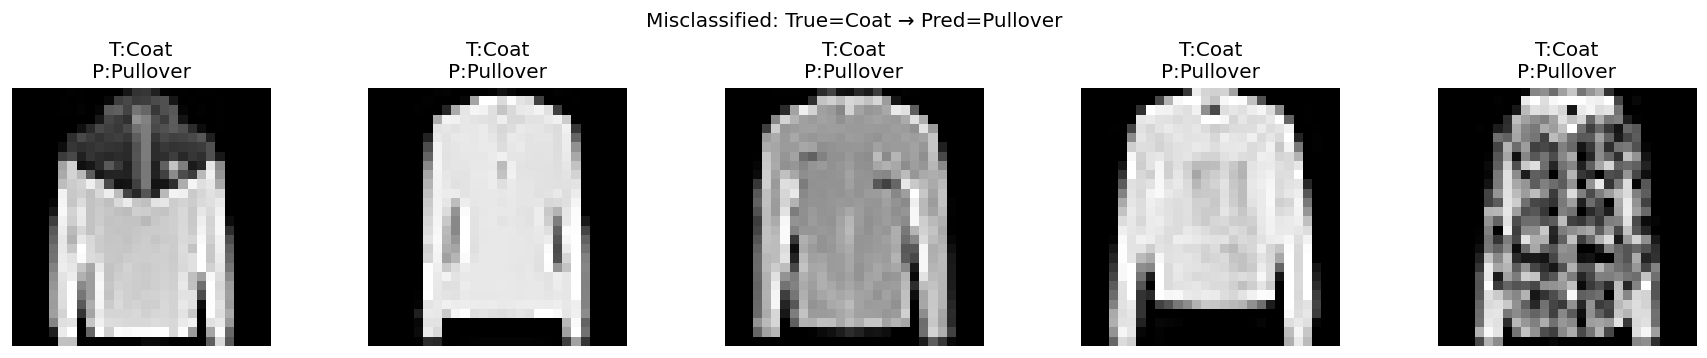

In [13]:

# Helper to display up to 5 misclassified examples for a given (true_i, pred_j)
def show_misclassified_for_pair(true_i, pred_j, max_imgs=5, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    idxs = np.where((y_test == true_i) & (y_test_pred == pred_j))[0]
    if len(idxs) == 0:
        print(f"No misclassifications for pair True={true_i}, Pred={pred_j}.")
        return
    sel = rng.choice(idxs, size=min(max_imgs, len(idxs)), replace=False)

    cols = min(5, len(sel))
    fig, axes = plt.subplots(1, cols, figsize=(3*cols, 3))
    if cols == 1:
        axes = [axes]
    for k, idx in enumerate(sel):
        axes[k].imshow(X_test[idx], cmap="gray")
        axes[k].axis("off")
        axes[k].set_title(f"T:{FASHION_CLASSES[true_i]}\nP:{FASHION_CLASSES[pred_j]}")
    plt.suptitle(f"Misclassified: True={FASHION_CLASSES[true_i]} → Pred={FASHION_CLASSES[pred_j]}")
    plt.tight_layout()
    fname = f"misclf_T{true_i}_P{pred_j}.png"
    plt.show()

# Display for top-3
for name_t, name_p, cnt, i, j in top3_named:
    print(f"Pair: True='{name_t}' Pred='{name_p}' — count={cnt}")
    show_misclassified_for_pair(i, j, max_imgs=5)



## 9) Timing & Computational Analysis (Discussion Prompts)

- **k-NN is a _lazy learner_**: No parametric training; it stores the dataset and defers work to query time.
- Observe reported **fit** vs **predict** times above. Usually:
  - **Fit** is fast.
  - **Predict** can be **slow**, especially with large datasets and high-dimensional inputs.
- **Trade-offs**:
  - Larger **k** often increases robustness but can blur class boundaries.
  - **Manhattan** vs **Euclidean**: performance can vary; Manhattan may be more robust to outliers in high-dim spaces.
  - **Standardization** is crucial to balance pixel scales.
  - **Memory** usage is higher than parametric models because all standardized vectors are stored.
